# 01 — Data Inspection

**Thesis:** Comparative Analysis of Machine Learning Algorithms for Predicting CVD Risk in a Tunisian Hospital Population

**Purpose of this notebook:** inspect the raw dataset exactly as received, without modifying, imputing, encoding, or deleting anything. All cleaning decisions in `02_Data_Cleaning.ipynb` are justified by the findings documented here.

**Contents**
1. Setup and data loading
2. Structural overview (shape, dtypes, columns)
3. Missing values
4. Duplicate rows
5. Categorical variables: unique values and frequencies
6. Numerical variables: ranges and descriptive statistics
7. Clinical plausibility checks (BMI consistency, blood-pressure consistency)
8. Structural / batch inspection
9. Target variable: class distribution and imbalance
10. Potential data leakage
11. Data-quality report (summary)


## 1. Setup and data loading

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)

# Project paths (relative -- portable across machines)
PROJECT_DIR = Path.cwd().parent
RAW_PATH = PROJECT_DIR / "data" / "raw" / "CVD_not_clean.csv"

df = pd.read_csv(RAW_PATH, sep=';')
df_original = df.copy()  # kept untouched as a reference; nothing below modifies df
print(f"Loaded {RAW_PATH} -- {df.shape[0]} rows, {df.shape[1]} columns.")
df.head()


Loaded /home/claude/ML_HOSPITAL/data/raw/CVD_not_clean.csv -- 1529 rows, 15 columns.


,Sex,Age,Weight (kg),Height (cm),BMI,Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Systolic BP,Diastolic BP,CVD Risk Level
0,F,32.0,69.1,171.0,23.6,248.0,78.0,111.0,N,Y,Low,N,125.0,79.0,INTERMEDIARY
1,F,55.0,118.7,169.0,41.6,162.0,50.0,135.0,Y,Y,High,Y,139.0,70.0,HIGH
2,M,NaN,NaN,183.0,26.9,103.0,73.0,114.0,N,N,High,Y,104.0,77.0,INTERMEDIARY
3,M,44.0,108.3,NaN,33.4,134.0,46.0,91.0,N,N,High,Y,140.0,83.0,INTERMEDIARY
4,F,32.0,99.5,186.0,28.8,146.0,64.0,141.0,Y,Y,High,N,144.0,83.0,INTERMEDIARY


## 2. Structural overview

In [2]:
print("Shape (rows, columns):", df.shape)
print()
print("Column names:")
for c in df.columns:
    print(f"  - {c}")


Shape (rows, columns): (1529, 15)

Column names:
  - Sex
  - Age
  - Weight (kg)
  - Height (cm)
  - BMI
  - Total Cholesterol (mg/dL)
  - HDL (mg/dL)
  - Fasting Blood Sugar (mg/dL)
  - Smoking Status
  - Diabetes Status
  - Physical Activity Level
  - Family History of CVD
  - Systolic BP
  - Diastolic BP
  - CVD Risk Level


In [3]:
dtype_table = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unique': df.nunique(),
    'sample_value': [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns]
})
dtype_table


,dtype,n_unique,sample_value
Sex,str,2,F
Age,float64,55,32.0
Weight (kg),float64,1019,69.1
Height (cm),float64,547,171.0
BMI,float64,787,23.6
Total Cholesterol (mg/dL),float64,201,248.0
HDL (mg/dL),float64,60,78.0
Fasting Blood Sugar (mg/dL),float64,128,111.0
Smoking Status,str,2,N
Diabetes Status,str,2,Y


**Observation.** Pandas infers all nine clinical measurements (`Age`, `Weight (kg)`, `Height (cm)`, `BMI`, `Total Cholesterol (mg/dL)`, `HDL (mg/dL)`, `Fasting Blood Sugar (mg/dL)`, `Systolic BP`, `Diastolic BP`) as `float64`, and the remaining six columns (`Sex`, `Smoking Status`, `Diabetes Status`, `Physical Activity Level`, `Family History of CVD`, `CVD Risk Level`) as text (`object`/`str`). This split matches the intended variable types: 9 numerical, 6 categorical (5 categorical predictors + the target).

## 3. Missing values

In [4]:
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_table = missing_table.sort_values('missing_count', ascending=False)
missing_table


,missing_count,missing_pct
Diastolic BP,82,5.36
Weight (kg),81,5.30
HDL (mg/dL),80,5.23
Age,78,5.10
Height (cm),74,4.84
Total Cholesterol (mg/dL),73,4.77
Systolic BP,71,4.64
Fasting Blood Sugar (mg/dL),67,4.38
BMI,64,4.19
Sex,0,0.00


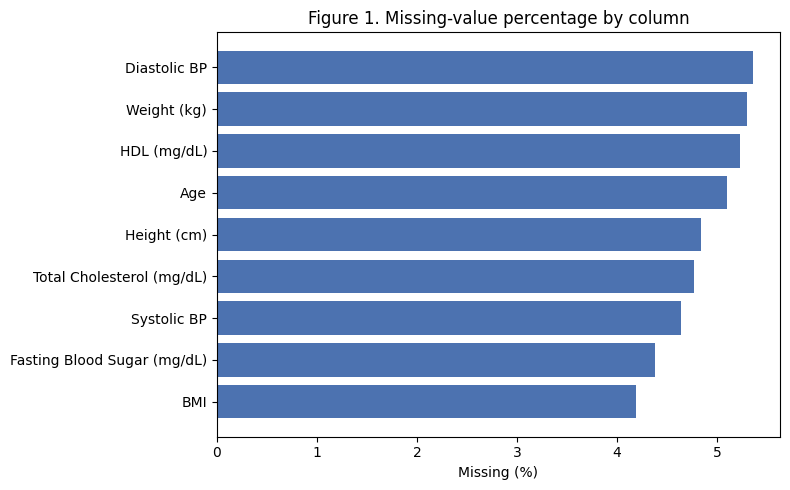

In [5]:
import matplotlib.pyplot as plt

FIGURES_DIR = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
plot_data = missing_table[missing_table['missing_count'] > 0]
ax.barh(plot_data.index, plot_data['missing_pct'], color='#4C72B0')
ax.set_xlabel('Missing (%)')
ax.set_title('Figure 1. Missing-value percentage by column')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb01_fig1_missing_values.png', dpi=150)
plt.show()


**Observation.** All 9 numerical clinical variables carry missing values, each in a narrow band of roughly 4.2%-5.4% of rows. None of the 6 categorical variables (including the target `CVD Risk Level`) has any missing value. The uniform, moderate missingness rate across numeric columns with no missingness in categoricals is consistent with independent, per-field data entry gaps rather than a systematic collection failure -- this will be documented in `02_Data_Cleaning.ipynb`.

## 4. Duplicate rows

In [6]:
n_full_dupes = df.duplicated(keep=False).sum()
print(f"Fully duplicated rows: {n_full_dupes}")

id_like_cols = [c for c in df.columns if c != 'CVD Risk Level']
n_dupes_excl_target = df.duplicated(subset=id_like_cols, keep=False).sum()
print(f"Duplicated on all predictor columns (target excluded): {n_dupes_excl_target}")


Fully duplicated rows: 0
Duplicated on all predictor columns (target excluded): 0


**Observation.** No duplicate rows were found, whether or not the target column is included in the comparison. No de-duplication step is required.

## 5. Categorical variables: unique values and frequencies

In [7]:
categorical_cols = ['Sex', 'Smoking Status', 'Diabetes Status',
                    'Physical Activity Level', 'Family History of CVD', 'CVD Risk Level']

for c in categorical_cols:
    print(f"--- {c} ---")
    print(df[c].value_counts(dropna=False))
    print(f"Unique values: {sorted(df[c].dropna().unique().tolist())}")
    print()


--- Sex ---
Sex
F    773
M    756
Name: count, dtype: int64
Unique values: ['F', 'M']

--- Smoking Status ---
Smoking Status
Y    789
N    740
Name: count, dtype: int64
Unique values: ['N', 'Y']

--- Diabetes Status ---
Diabetes Status
Y    777
N    752
Name: count, dtype: int64
Unique values: ['N', 'Y']

--- Physical Activity Level ---
Physical Activity Level
High        521
Moderate    512
Low         496
Name: count, dtype: int64
Unique values: ['High', 'Low', 'Moderate']

--- Family History of CVD ---
Family History of CVD
N    780
Y    749
Name: count, dtype: int64
Unique values: ['N', 'Y']

--- CVD Risk Level ---
CVD Risk Level
HIGH            728
INTERMEDIARY    581
LOW             220
Name: count, dtype: int64
Unique values: ['HIGH', 'INTERMEDIARY', 'LOW']



## 6. Numerical variables: ranges and descriptive statistics

In [8]:
numerical_cols = ['Age', 'Weight (kg)', 'Height (cm)', 'BMI',
                  'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)',
                  'Systolic BP', 'Diastolic BP']
desc = df[numerical_cols].describe().T
desc['missing'] = df[numerical_cols].isna().sum()
desc


,count,mean,std,min,25%,50%,75%,max,missing
Age,1451.0,47.025500,12.421063,25.0,37.000,46.0000,55.0000,79.00,78
Weight (kg),1448.0,85.917427,21.012580,50.1,67.050,86.6145,105.0000,120.00,81
Height (cm),1455.0,175.390600,11.251527,150.0,166.000,175.6940,184.2085,199.96,74
BMI,1465.0,28.465997,7.038685,15.0,22.629,28.1590,34.0000,46.20,64
Total Cholesterol (mg/dL),1456.0,198.539148,57.794099,100.0,150.000,197.0000,249.0000,300.00,73
HDL (mg/dL),1449.0,56.197378,16.066754,30.0,42.000,56.0000,70.0000,89.00,80
Fasting Blood Sugar (mg/dL),1462.0,117.485636,30.289174,70.0,92.000,115.0000,138.0000,198.00,67
Systolic BP,1458.0,125.627572,22.112099,90.0,107.000,125.0000,141.0000,179.00,71
Diastolic BP,1447.0,82.917761,14.731277,60.0,71.000,82.0000,93.0000,119.00,82


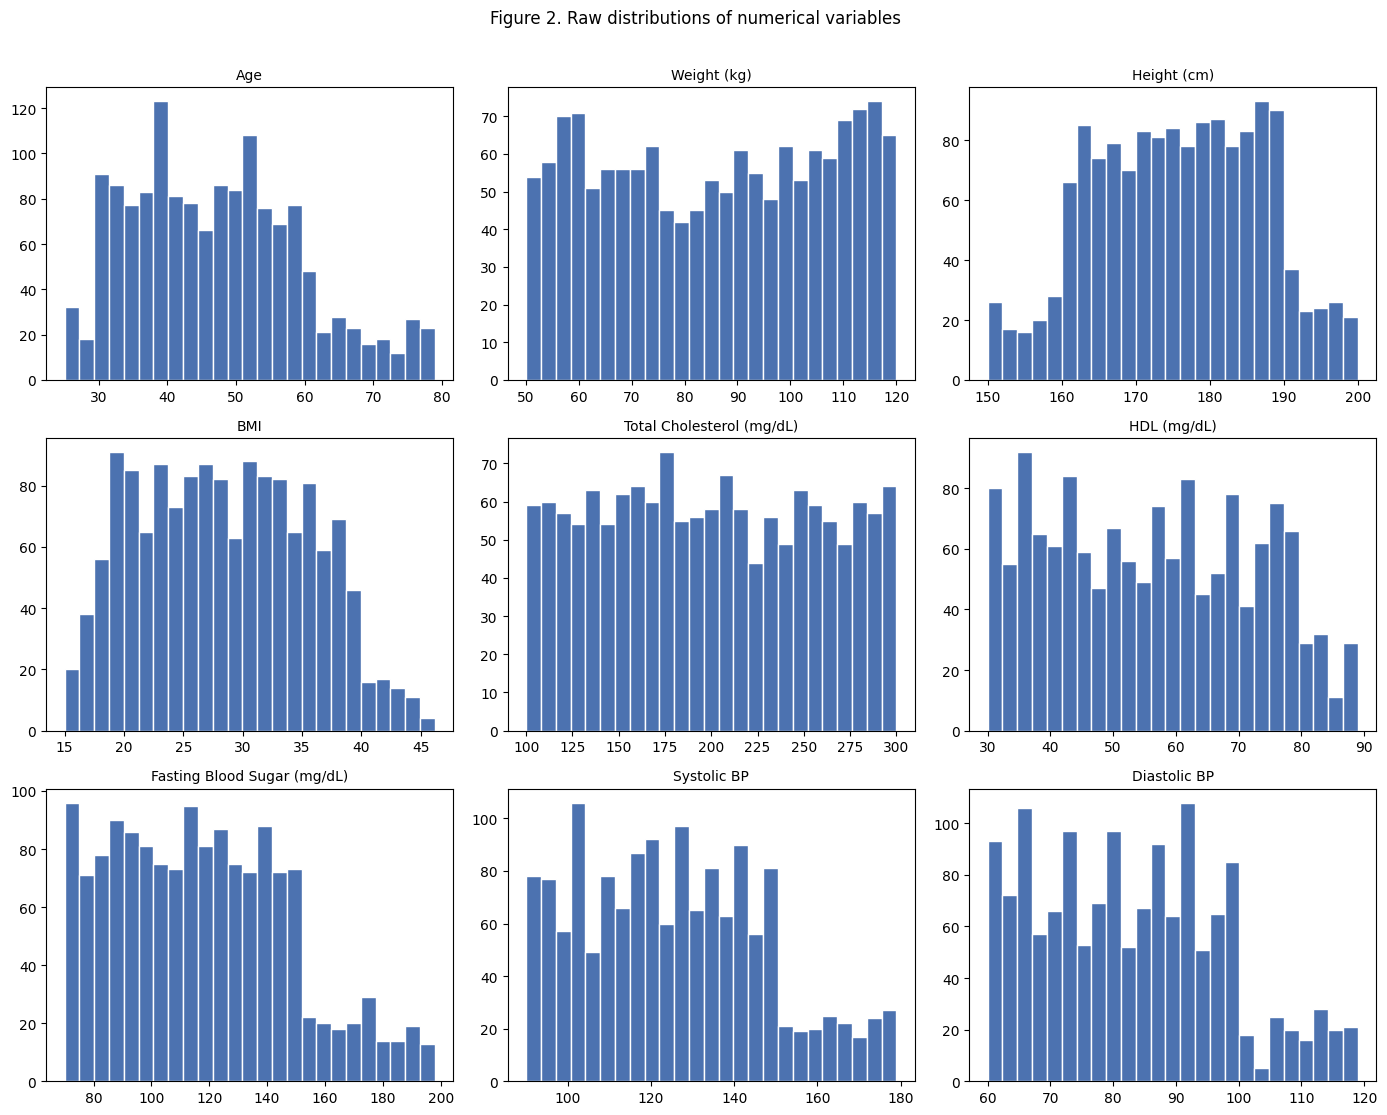

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, c in zip(axes.ravel(), numerical_cols):
    ax.hist(df[c].dropna(), bins=25, color='#4C72B0', edgecolor='white')
    ax.set_title(c, fontsize=10)
fig.suptitle('Figure 2. Raw distributions of numerical variables', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb01_fig2_raw_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Clinical plausibility checks
### 7.1 BMI consistency with Weight and Height

In [10]:
mask = df[['Weight (kg)', 'Height (cm)', 'BMI']].notna().all(axis=1)
bmi_recalculated = df.loc[mask, 'Weight (kg)'] / (df.loc[mask, 'Height (cm)'] / 100) ** 2
bmi_diff = (bmi_recalculated - df.loc[mask, 'BMI']).abs()

print(f"Rows with Weight, Height and BMI all present: {mask.sum()} / {len(df)}")
print(f"Rows where |recalculated BMI - recorded BMI| > 1.0 kg/m^2: {(bmi_diff > 1.0).sum()} "
      f"({(bmi_diff > 1.0).mean()*100:.1f}% of checkable rows)")
bmi_diff.describe()


Rows with Weight, Height and BMI all present: 1317 / 1529
Rows where |recalculated BMI - recorded BMI| > 1.0 kg/m^2: 431 (32.7% of checkable rows)


count    1317.000000
mean        3.022872
std         5.508018
min         0.000051
25%         0.020305
50%         0.040025
75%         3.968987
max        31.421891
dtype: float64

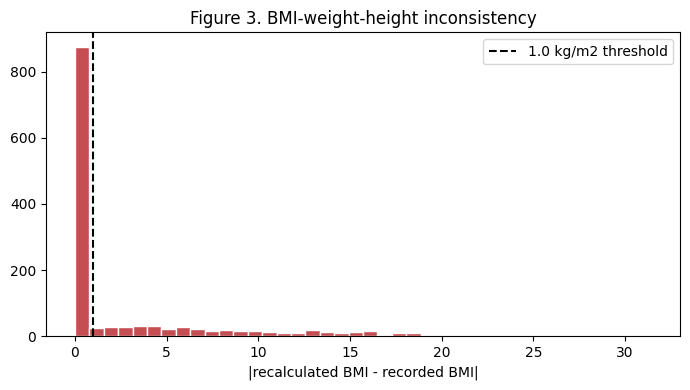

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(bmi_diff, bins=40, color='#C44E52', edgecolor='white')
ax.axvline(1.0, color='black', linestyle='--', label='1.0 kg/m2 threshold')
ax.set_xlabel('|recalculated BMI - recorded BMI|')
ax.set_title('Figure 3. BMI-weight-height inconsistency')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb01_fig3_bmi_inconsistency.png', dpi=150)
plt.show()


**Observation -- important finding.** The distribution of `bmi_diff` is clearly bimodal: a large group of rows is consistent to within rounding error, while a second, substantial group (roughly a third of checkable rows) shows large discrepancies, up to >30 kg/m2. This is investigated further in Section 8. The recorded `BMI` column cannot be trusted uniformly across the dataset.

### 7.2 Systolic / Diastolic blood pressure consistency

In [12]:
bp_mask = df[['Systolic BP', 'Diastolic BP']].notna().all(axis=1)
invalid_bp = df.loc[bp_mask, 'Diastolic BP'] >= df.loc[bp_mask, 'Systolic BP']

print(f"Rows with both BP fields present: {bp_mask.sum()} / {len(df)}")
print(f"Rows where Diastolic BP >= Systolic BP (physiologically invalid): {invalid_bp.sum()} "
      f"({invalid_bp.mean()*100:.1f}%)")


Rows with both BP fields present: 1378 / 1529
Rows where Diastolic BP >= Systolic BP (physiologically invalid): 65 (4.7%)


**Observation.** Diastolic pressure should always be lower than systolic pressure. A small but non-trivial fraction of rows (about one in twenty) violates this, and will need explicit handling in cleaning rather than being treated as ordinary noise.

## 8. Structural / batch inspection

The decimal precision of the continuous measurements (e.g. `Weight (kg)`) is not uniform across the file: some rows report one decimal place, others three. This is investigated as a possible sign that the file concatenates two data sources.

In [13]:
df_str = pd.read_csv(RAW_PATH, sep=';', dtype=str)

def n_decimals(x):
    if pd.isna(x):
        return np.nan
    return len(str(x).split('.')[-1]) if '.' in str(x) else 0

decimals = df_str['Weight (kg)'].apply(n_decimals)
print(decimals.value_counts())

three_dec_idx = decimals[decimals == 3].index
one_dec_idx = decimals[decimals == 1].index
print()
print("First row with 3-decimal precision weight:", three_dec_idx.min())


Weight (kg)
1.0    841
3.0    455
0.0     96
2.0     56
Name: count, dtype: int64

First row with 3-decimal precision weight: 986


In [14]:
BATCH_SPLIT = int(three_dec_idx.min())
df['_batch'] = np.where(df.index < BATCH_SPLIT, 'A (rows 0-%d)' % (BATCH_SPLIT-1), 'B (rows %d-%d)' % (BATCH_SPLIT, len(df)-1))

print(df['_batch'].value_counts())
print()
comparison = df.groupby('_batch')[numerical_cols].agg(['min', 'max', 'mean']).T
comparison


_batch
A (rows 0-985)       986
B (rows 986-1528)    543
Name: count, dtype: int64



_batch                            A (rows 0-985)  B (rows 986-1528)
Age                         min        30.000000          25.000000
                            max        60.000000          79.000000
                            mean       44.569755          51.529297
Weight (kg)                 min        50.100000          50.307000
                            max       120.000000         119.806000
                            mean       85.991542          85.782753
Height (cm)                 min       160.000000         150.000000
                            max       190.000000         199.960000
                            mean      175.204909         175.726492
BMI                         min        15.000000          18.508000
                            max        46.200000          39.979000
                            mean       28.193524          28.956761
Total Cholesterol (mg/dL)   min       100.000000         100.000000
                            max       300.000000         299.000000
                            mean      196.556150         202.097889
HDL (mg/dL)                 min        30.000000          30.000000
                            max        80.000000          89.000000
                            mean       54.150480          59.943359
Fasting Blood Sugar (mg/dL) min        70.000000          70.000000
                            max       150.000000         198.000000
                            mean      110.095689         131.238748
Systolic BP                 min        90.000000          90.000000
                            max       150.000000         179.000000
                            mean      120.168455         135.300380
Diastolic BP                min        60.000000          60.000000
                            max       100.000000         119.000000
                            mean       79.454936          89.184466

In [15]:
print("Target class balance by batch:")
print(pd.crosstab(df['_batch'], df['CVD Risk Level'], normalize='index').round(3) * 100)
print()

print("BMI inconsistency rate (>1.0 kg/m^2) by batch:")
mask2 = df[['Weight (kg)', 'Height (cm)', 'BMI', '_batch']].notna().all(axis=1)
sub = df.loc[mask2].copy()
sub['bmi_calc'] = sub['Weight (kg)'] / (sub['Height (cm)'] / 100) ** 2
sub['diff'] = (sub['bmi_calc'] - sub['BMI']).abs()
print(sub.groupby('_batch')['diff'].apply(lambda s: (s > 1.0).mean() * 100).round(1))
print()

print("Diastolic >= Systolic rate by batch:")
bp_mask2 = df[['Systolic BP', 'Diastolic BP', '_batch']].notna().all(axis=1)
sub2 = df.loc[bp_mask2].copy()
sub2['bad'] = sub2['Diastolic BP'] >= sub2['Systolic BP']
print(sub2.groupby('_batch')['bad'].mean().mul(100).round(1))


Target class balance by batch:
CVD Risk Level     HIGH  INTERMEDIARY   LOW
_batch                                     
A (rows 0-985)     54.3          40.5   5.3
B (rows 986-1528)  35.5          33.5  30.9

BMI inconsistency rate (>1.0 kg/m^2) by batch:
_batch
A (rows 0-985)        0.0
B (rows 986-1528)    91.5
Name: diff, dtype: float64

Diastolic >= Systolic rate by batch:
_batch
A (rows 0-985)       1.9
B (rows 986-1528)    9.6
Name: bad, dtype: float64


**Observation -- key structural finding.** The two row segments differ systematically, not just in numeric precision: age range, physiological extremes, target balance, BMI reliability and BP validity all differ between the segments. This strongly suggests the raw file concatenates two distinct data collections rather than a single homogeneous cohort. This is documented as a methodological limitation and is never used as a predictive feature; a diagnostic-only batch indicator is reconstructed later purely for QA.

## 9. Target variable: class distribution and imbalance

In [16]:
target_counts = df['CVD Risk Level'].value_counts()
target_pct = (target_counts / len(df) * 100).round(1)
target_table = pd.DataFrame({'count': target_counts, 'pct': target_pct})
target_table = target_table.reindex(['LOW', 'INTERMEDIARY', 'HIGH'])
target_table


,count,pct
CVD Risk Level,,
LOW,220,14.4
INTERMEDIARY,581,38.0
HIGH,728,47.6


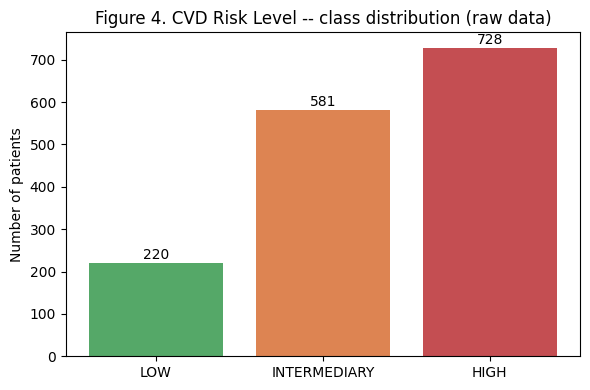

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(target_table.index, target_table['count'], color=['#55A868', '#DD8452', '#C44E52'])
ax.set_title('Figure 4. CVD Risk Level -- class distribution (raw data)')
ax.set_ylabel('Number of patients')
for i, v in enumerate(target_table['count']):
    ax.text(i, v + 10, str(v), ha='center')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb01_fig4_target_distribution.png', dpi=150)
plt.show()


**Observation.** The target is moderately imbalanced: `HIGH` is the majority class (~47.6%), `INTERMEDIARY` is second (~38.0%), and `LOW` is a clear minority (~14.4%). This is not extreme imbalance, but it is large enough that macro-averaged metrics (Macro F1, per-class recall) will matter more than raw accuracy in the later modelling stage.

## 10. Potential data leakage

In [18]:
order = {'LOW': 0, 'INTERMEDIARY': 1, 'HIGH': 2}
df['_risk_ordinal'] = df['CVD Risk Level'].map(order)

corr_with_target = df[numerical_cols + ['_risk_ordinal']].corr()['_risk_ordinal'].drop('_risk_ordinal')
corr_with_target.sort_values(key=abs, ascending=False)


HDL (mg/dL)                   -0.177690
BMI                            0.151570
Weight (kg)                    0.132350
Total Cholesterol (mg/dL)      0.126315
Systolic BP                   -0.098143
Diastolic BP                  -0.060886
Fasting Blood Sugar (mg/dL)   -0.050895
Height (cm)                   -0.017557
Age                            0.010414
Name: _risk_ordinal, dtype: float64

In [19]:
print("Mean ordinal risk (0=LOW, 1=INTERMEDIARY, 2=HIGH) by categorical predictor:")
for c in ['Sex', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD']:
    print(f"\n{c}:")
    print(df.groupby(c)['_risk_ordinal'].mean().round(3))


Mean ordinal risk (0=LOW, 1=INTERMEDIARY, 2=HIGH) by categorical predictor:

Sex:
Sex
F    1.353
M    1.311
Name: _risk_ordinal, dtype: float64

Smoking Status:
Smoking Status
N    1.211
Y    1.446
Name: _risk_ordinal, dtype: float64

Diabetes Status:
Diabetes Status
N    1.214
Y    1.447
Name: _risk_ordinal, dtype: float64

Physical Activity Level:
Physical Activity Level
High        1.246
Low         1.492
Moderate    1.266
Name: _risk_ordinal, dtype: float64

Family History of CVD:
Family History of CVD
N    1.204
Y    1.466
Name: _risk_ordinal, dtype: float64


**Observation.** No single numerical variable correlates strongly with the target (all |r| < 0.2), and no categorical variable shows a large mean-risk gap between its levels. This pattern is consistent with a risk label generated from a combination of several moderately informative factors plus noise, rather than one that leaks directly from a single recorded field. No leakage variable is dropped at this stage.

## 11. Data-quality report -- summary

| Check | Finding | Action needed in cleaning |
|---|---|---|
| Shape | 1,529 rows x 15 columns | -- |
| Missing values | 4.2%-5.4% missing in each of the 9 numeric columns; 0% missing in categoricals/target | Impute numeric columns |
| Duplicates | 0 duplicate rows | -- |
| Categorical values | Clean, consistent labels, no typos | Defensive standardization only |
| BMI vs Weight/Height | ~33% of checkable rows inconsistent (>1 kg/m2) | Recalculate BMI from Weight & Height for all rows |
| Diastolic >= Systolic BP | ~4.7% of checkable rows | Treat as invalid, resolve explicitly |
| Batch structure | Two concatenated cohorts differing in several respects | Preserve as traceable diagnostic only |
| Target distribution | Moderate imbalance: HIGH 47.6%, INTERMEDIARY 38.0%, LOW 14.4% | Use macro-averaged metrics later; consider SMOTE/class weights |
| Data leakage | No single variable strongly predicts the target (|r| < 0.2) | No variables dropped |

**Conclusion.** The dataset is usable but requires deliberate cleaning: numeric imputation, a full BMI recalculation, explicit resolution of invalid BP pairs, and awareness of the two-batch structure. All issues are addressed through documented, reversible transformations in `02_Data_Cleaning.ipynb`, which starts again from the untouched raw file.